# Milestone 1: Week 1 - Polynomial and Interaction Terms

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#### Polynomial Terms

In [2]:
census = pd.read_csv('..\Processed Data\Census Demographics.csv')
census.head()

,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,total_pop_1970,total_pop_1980,total_pop_1990,...,pop_75_84_years_1990,pop_75_84_years_2000,pop_75_84_years_2010,pop_75_84_years_2020,pop_85_years_and_older_1970,pop_85_years_and_older_1980,pop_85_years_and_older_1990,pop_85_years_and_older_2000,pop_85_years_and_older_2010,pop_85_years_and_older_2020
0,G0100010,Alabama,1,10,Autauga County,1,10,24460.0,32259.0,34222.0,...,1107.0,1342.0,1982.0,2896.0,136.0,181.0,299.0,428.0,551.0,927.0
1,G0100030,Alabama,1,10,Baldwin County,3,30,59382.0,78556.0,98280.0,...,4698.0,7184.0,9532.0,15467.0,469.0,676.0,1160.0,2164.0,3233.0,4606.0
2,G0100050,Alabama,1,10,Barbour County,5,50,22543.0,24756.0,25417.0,...,1303.0,1323.0,1228.0,1472.0,213.0,252.0,334.0,512.0,443.0,492.0
3,G0100070,Alabama,1,10,Bibb County,7,70,13812.0,15723.0,16576.0,...,773.0,755.0,904.0,1111.0,122.0,149.0,220.0,334.0,279.0,353.0
4,G0100090,Alabama,1,10,Blount County,9,90,26853.0,36459.0,39248.0,...,1796.0,2077.0,2552.0,3441.0,174.0,288.0,408.0,716.0,808.0,1053.0


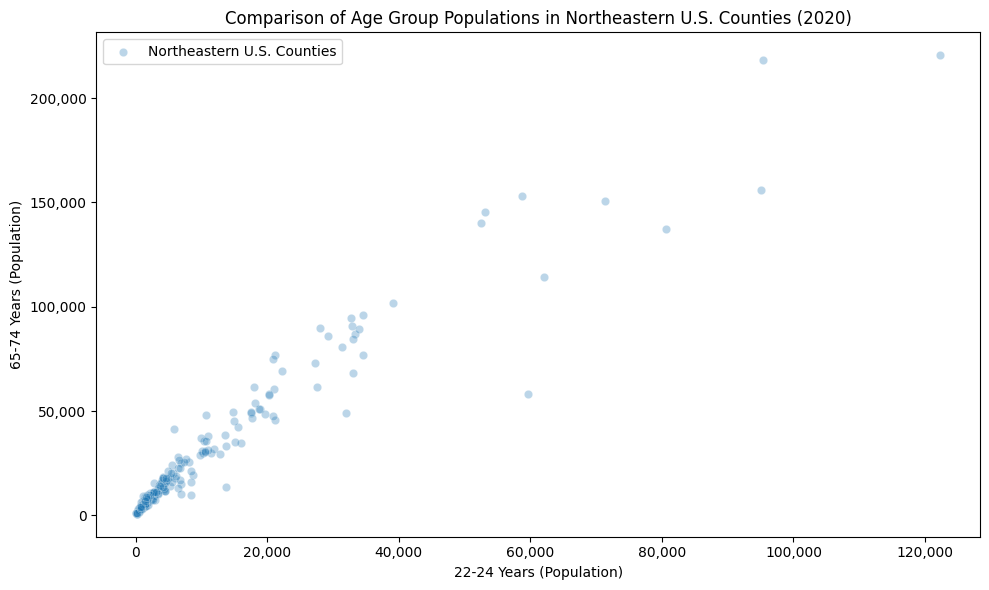

In [3]:
# Took this graph from ModB Semester 2 Milestone 3

northeast_states = [
'Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'Rhode Island',
'Vermont', 'New Jersey', 'New York', 'Pennsylvania'
]

region = census[census['STATE'].isin(northeast_states)]

plt.figure(figsize=(10, 6))

sns.scatterplot(data=region, x='pop_22_24_years_2020', y='pop_65_74_years_2020', alpha=0.3, label='Northeastern U.S. Counties')
plt.xlabel('22-24 Years (Population)')
plt.ylabel('65-74 Years (Population)')
plt.title('Comparison of Age Group Populations in Northeastern U.S. Counties (2020)')
# Format x and y axis with commas
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.tight_layout()
plt.show()


In [4]:
col = 'pop_22_24_years_2020'

X = pd.DataFrame(region['pop_22_24_years_2020'])
X_squared = (X**2).rename({'pop_22_24_years_2020': 'pop_22_24_years_2020_squared'})
X_with_square = pd.concat([X, X_squared], axis=1)

y_true = region['pop_65_74_years_2020']

X_train, X_test, X_sq_train, X_sq_test, y_train, y_test = train_test_split(
    X, X_with_square, y_true, test_size=0.2, random_state=42
)

# Linear Model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

a_lr = model_lr.coef_[0]
int_lr = model_lr.intercept_

# Polynomial Model
model_poly = LinearRegression()
model_poly.fit(X_sq_train, y_train)
y_pred_poly = model_poly.predict(X_sq_test)

b_poly = model_poly.coef_[0]
a_poly = model_poly.coef_[1]
int_poly = model_poly.intercept_

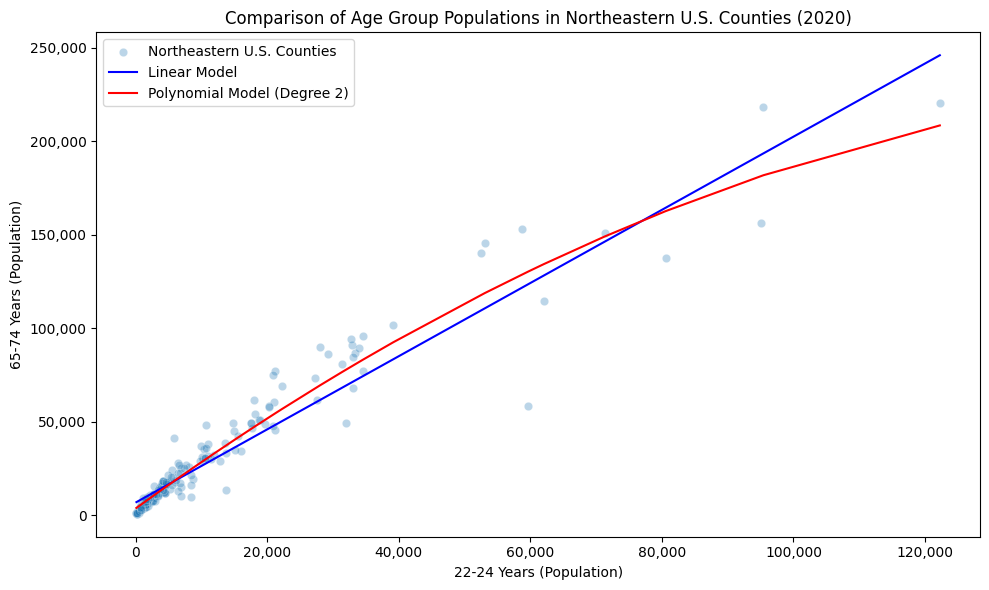

    Linear model fitted equation:       y = 1.9558088439538182x + 6772.844539825208
    Polynomial model fitted equation:   y = -7.145492132809542e-06x^2 + 2.5483202977531696x + 3616.384618515829


In [5]:
# Only for the purpose of drawing the full model lines
y_pred_lr_full = model_lr.predict(X)
y_pred_poly_full = model_poly.predict(X_with_square)

# Need to flatten and sort values so polynomial model prediction line is not messed up
X_flat = X.values.flatten()
sorted_indices = np.argsort(X_flat)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=region, x='pop_22_24_years_2020', y='pop_65_74_years_2020', alpha=0.3, label='Northeastern U.S. Counties')

plt.plot(X_flat[sorted_indices], y_pred_lr_full[sorted_indices], color='blue', label='Linear Model')
plt.plot(X_flat[sorted_indices], y_pred_poly_full[sorted_indices], color='red', label='Polynomial Model (Degree 2)')


plt.xlabel('22-24 Years (Population)')
plt.ylabel('65-74 Years (Population)')
plt.title('Comparison of Age Group Populations in Northeastern U.S. Counties (2020)')
# Format x and y axis with commas
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.legend()
plt.tight_layout()
plt.show()

print(f"    Linear model fitted equation:       y = {a_lr}x + {int_lr}")
print(f"    Polynomial model fitted equation:   y = {a_poly}x^2 + {b_poly}x + {int_poly}")

In [6]:
# Linear Model Errors
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Polynomial Model Errors
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("--- Linear Model Performance ---")
print(f"Mean Absolute Error: {mae_lr:,.0f} people")
print(f"Root Mean Squared:   {rmse_lr:,.0f} people")
print(f"R-squared:           {r2_lr:.4f}")

print("\n--- Polynomial Model (Degree 2) Performance ---")
print(f"Mean Absolute Error: {mae_poly:,.0f} people")
print(f"Root Mean Squared:   {rmse_poly:,.0f} people")
print(f"R-squared:           {r2_poly:.4f}")

--- Linear Model Performance ---
Mean Absolute Error: 6,074 people
Root Mean Squared:   9,678 people
R-squared:           0.8986

--- Polynomial Model (Degree 2) Performance ---
Mean Absolute Error: 4,239 people
Root Mean Squared:   7,058 people
R-squared:           0.9461


Overall, the polynomial model for predicting the 65-74 year old population was better than the linear model. There is a slight curve to the data and the polynomial model was able to capture that curve. Both models are good (linear explained 89.86% of the variance while polynomial is 94.61%), however the polynomial definitely is an improvement with a lower error.

In [7]:
NCHS_life_expectancy = pd.read_csv(r'..\Processed Data\nchs_life_expect_encoded.csv')
NCHS_life_expectancy.head()

,Age-adjusted Death Rate,Average Life Expectancy (Years),Year,Race_Black,Race_White,Sex_Female,Sex_Male
0,2518.0,47.3,1900,False,False,False,False
1,2473.1,49.1,1901,False,False,False,False
2,2301.3,51.5,1902,False,False,False,False
3,2379.0,50.5,1903,False,False,False,False
4,2502.5,47.6,1904,False,False,False,False


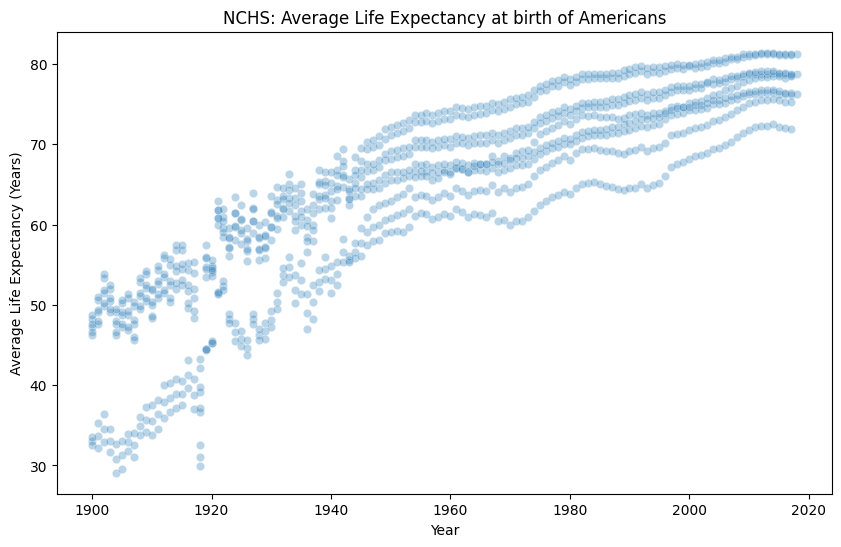

In [8]:
plt.figure(figsize=(10,6))

# Scatter the raw data
sns.scatterplot(
    data=NCHS_life_expectancy, 
    x='Year', 
    y='Average Life Expectancy (Years)', 
    alpha=0.3,
)
plt.title('NCHS: Average Life Expectancy at birth of Americans')
plt.show()

In [9]:
NCHS_life_expectancy = NCHS_life_expectancy.dropna()

col = 'Average Life Expectancy (Years)'

X = pd.DataFrame(NCHS_life_expectancy['Year'])
X_squared = (X**2).rename({'Year': 'Year_squared'})
X_with_square = pd.concat([X, X_squared], axis=1)

y_true = NCHS_life_expectancy[col]

X_train, X_test, X_sq_train, X_sq_test, y_train, y_test = train_test_split(
    X, X_with_square, y_true, test_size=0.2, random_state=42
)

# Linear Model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

a_lr = model_lr.coef_[0]
int_lr = model_lr.intercept_

# Polynomial Model
model_poly = LinearRegression()
model_poly.fit(X_sq_train, y_train)
y_pred_poly = model_poly.predict(X_sq_test)

b_poly = model_poly.coef_[0]
a_poly = model_poly.coef_[1]
int_poly = model_poly.intercept_

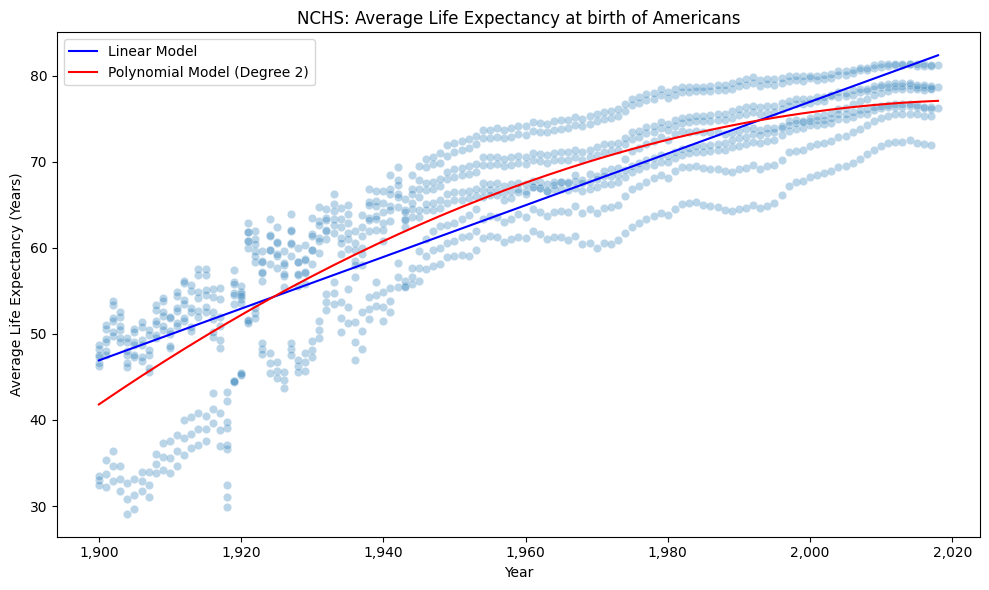

    Linear model fitted equation:       y = 0.30038762217818116x + (-523.8158126902754)
    Polynomial model fitted equation:   y = -0.0022494124645642x^2 + 9.112078158509362x + (-9150.766352061359)


In [10]:
# Only for the purpose of drawing the full model lines
y_pred_lr_full = model_lr.predict(X)
y_pred_poly_full = model_poly.predict(X_with_square)

# Need to flatten and sort values so polynomial model prediction line is not messed up
X_flat = X.values.flatten()
sorted_indices = np.argsort(X_flat)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=NCHS_life_expectancy, x='Year', y='Average Life Expectancy (Years)', alpha=0.3)

plt.plot(X_flat[sorted_indices], y_pred_lr_full[sorted_indices], color='blue', label='Linear Model')
plt.plot(X_flat[sorted_indices], y_pred_poly_full[sorted_indices], color='red', label='Polynomial Model (Degree 2)')


plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (Years)')
plt.title('NCHS: Average Life Expectancy at birth of Americans')
# Format x and y axis with commas
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.legend()
plt.tight_layout()
plt.show()

print(f"    Linear model fitted equation:       y = {a_lr}x + ({int_lr})")
print(f"    Polynomial model fitted equation:   y = {a_poly}x^2 + {b_poly}x + ({int_poly})")

In [11]:
# Linear Model Errors
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Polynomial Model Errors
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("--- Linear Model Performance ---")
print(f"Mean Absolute Error: {mae_lr:,.4f} years")
print(f"Root Mean Squared:   {rmse_lr:,.4f} years")
print(f"R-squared:           {r2_lr:.4f}")

print("\n--- Polynomial Model (Degree 2) Performance ---")
print(f"Mean Absolute Error: {mae_poly:,.4f} years")
print(f"Root Mean Squared:   {rmse_poly:,.4f} years")
print(f"R-squared:           {r2_poly:.4f}")

--- Linear Model Performance ---
Mean Absolute Error: 4.7249 years
Root Mean Squared:   6.0305 years
R-squared:           0.7508

--- Polynomial Model (Degree 2) Performance ---
Mean Absolute Error: 4.1751 years
Root Mean Squared:   5.3522 years
R-squared:           0.8037


In predicting average life expectancy at birth, the polynomial model explained more of the variance of the data and has slightly lower errors in its predictions compared to the linear model. Now, I am going to address interaction terms that might be relevant to the data in predicting average life expectancy.

#### Interaction Terms, Variance Inflation Factor, and Multicollinearity

In [12]:
NCHS_life_expectancy_copy = NCHS_life_expectancy.copy()
NCHS_life_expectancy_copy['Year_x_Female'] = NCHS_life_expectancy_copy['Year'] * NCHS_life_expectancy_copy['Sex_Female']

features = ['Year', 'Sex_Female', 'Year_x_Female']
X_interaction = NCHS_life_expectancy_copy[features]

# Forcing categorical True/False features to be numeric so SM accepts it
X_interaction = X_interaction.astype(float)

X_interaction = sm.add_constant(X_interaction)

y = NCHS_life_expectancy_copy['Average Life Expectancy (Years)']

model_interaction = sm.OLS(y, X_interaction)
results = model_interaction.fit()

print(results.summary())

                                   OLS Regression Results                                  
Dep. Variable:     Average Life Expectancy (Years)   R-squared:                       0.783
Model:                                         OLS   Adj. R-squared:                  0.783
Method:                              Least Squares   F-statistic:                     1277.
Date:                             Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                                     20:51:17   Log-Likelihood:                -3329.1
No. Observations:                             1065   AIC:                             6666.
Df Residuals:                                 1061   BIC:                             6686.
Df Model:                                        3                                         
Covariance Type:                         nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975

In [13]:
print("\n--- Variance Inflation Factor (VIF) ---")
vif_data = pd.DataFrame()
vif_data["Feature"] = X_interaction.columns
vif_data["VIF Score"] = [variance_inflation_factor(X_interaction.values, i) for i in range(len(X_interaction.columns))]
print(vif_data)


--- Variance Inflation Factor (VIF) ---
         Feature    VIF Score
0          const  4932.890272
1           Year     1.500000
2     Sex_Female  3288.593515
3  Year_x_Female  3289.093515


Findings:
  - P value for interaction term `Year_x_Female` is 0.008 which is less than 0.05 meaning that the interaction is highly unlikely to be caused by random chance alone.
  - The coefficient for the baseline `Year` is 0.2923 while `Year_x_Female` is 0.0279.
  - The VIF scores for everything except `Year` are very concerning because of how high they are. According to [Penn State University,](https://online.stat.psu.edu/stat462/node/180/) a VIF of 1 mans that there is no correlation with the variables and the feature's variance is not inflated, a VIF above 4 warrants further investigation, while VIF of >= 10 are signs of serious multicollinearity requiring correction. With features 2 and 3 being in the thousands, this means there is extreme multicollinearity that must be corrected.
    - `Sex_Female`: 3288.59
    - `Year_x_Female`: 3289.09
      - Because these are so high, and since my model is limited in the amount of features I included, it is obvious to tell that there is high correlation with `Sex_Female` and `Year_x_Female`. This is obvious because both share the `Sex_Female` feature.

Interpretaton:
The OLS model from StatsModels explains 78.3% of the variance in `Average Life Expectancy (Years)`. The baseline `Sex_Male` was omitted in order to analyze the interaction between `Sex_Female` and `Year` and how it affects `Average Life Expectancy (Years)`. The `Year` coefficent is 0.2923 meaning that for every one-unit increase in the calendar year, the predicted baseline life expectancy increases by an additive constant of 0.2923 years. When comparing this to the `Sex_Female` interaction, `Year_x_Female`, it has a positive coefficient of 0.0279. Alongside being statistically significant, p = 0.008 which is less than p = 0.05, this shows that female average life expectancy grew at an additional rate of 0.0279 years per calendar year. This means that the result for female average life expectancy grows approximately 0.2923 + 0.0279 = 0.3202 years for every calendar year. However, there is strong multicollinearity when it comes to this model. This is because `Year_x_Female` is directly calculated from `Year` and `Sex_Female`. To address this, it was expected to have strong multicollinearity when building this model. If I were to build this model for a specific purpose, I could consider using algorithms to conduct feature selection in order to only use the relevant features capturing enough information to generalize. But, in this case I am simply exploring the data and seeing how features interact with one another to predict `Average Life Expectancy (Years)` and gather insights for my capstone based on health disparities in the United States. Understanding that there is a difference in male and female life expectancy will be crucial when conducting more nuanced analyses with my other datasets. To practice, I will get the VIF scores and center the data before introducing interaction term to see if the interaction term remains significant.


In [14]:
life_expect_centered = NCHS_life_expectancy.copy()

mean_year = life_expect_centered['Year'].mean()


# Centering Year data and adding interactions
life_expect_centered['Year_centered'] = life_expect_centered['Year'] - mean_year
life_expect_centered['Year_x_Female_centered'] = life_expect_centered['Year_centered'] * life_expect_centered['Sex_Female']

# OLS Model with centered data
features_centered = ['Year_centered', 'Sex_Female', 'Year_x_Female_centered']
X = life_expect_centered[features_centered].astype(float)
X_centered = sm.add_constant(X)
y = life_expect_centered['Average Life Expectancy (Years)']

model_centered = sm.OLS(y, X_centered)
results_centered = model_centered.fit()
print("Centered Data OLS Model:")
print(results_centered.summary())

Centered Data OLS Model:
                                   OLS Regression Results                                  
Dep. Variable:     Average Life Expectancy (Years)   R-squared:                       0.783
Model:                                         OLS   Adj. R-squared:                  0.783
Method:                              Least Squares   F-statistic:                     1277.
Date:                             Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                                     20:51:17   Log-Likelihood:                -3329.1
No. Observations:                             1065   AIC:                             6666.
Df Residuals:                                 1061   BIC:                             6686.
Df Model:                                        3                                         
Covariance Type:                         nonrobust                                         
                             coef    std err          t

In [15]:
print("\n--- Variance Inflation Factor (VIF) ---")
vif_data_centered = pd.DataFrame()
vif_data_centered["Feature"] = X_centered.columns
vif_data_centered["VIF Score"] = [variance_inflation_factor(X_centered.values, i) for i in range(len(X_centered.columns))]
print(vif_data_centered)


--- Variance Inflation Factor (VIF) ---
                  Feature  VIF Score
0                   const        1.5
1           Year_centered        1.5
2              Sex_Female        1.0
3  Year_x_Female_centered        1.5


Findings:
  - P value for interaction term `Year_x_Female_centered` is 0.008 which is less than 0.05 meaning that the interaction is highly unlikely to be caused by random chance alone.
  - The coefficient for the baseline `Year_centered` is 0.2923 while `Year_x_Female_centered` is 0.0279.
  - The VIF scores are all low now, meaning there is little to no multicollinearity and the variance is not inflated as much compared to the original model without centering the data.

Interpretaton:
After centering the data, the VIF scores significantly decreased to safe levels (1.5 and below), which means that the extreme multicollinearity in the previous model was simply structural. Because the variance is no longer artificially inflated, we can furhter trust the statistical significance of the coefficients. This model confirms that the hypothesis of females' `Average Life Expectancy (Years)` grew at a faster rate over time compared to males and that the baseline life expectancy is overall higher than the male baseline.

Model formulas:
  - Original OLS Model:   
    - Female: `Average Life Expectancy (Years)` = -560.0004 + 0.3202(`Year`)
    - Male:   `Average Life Expectancy (Years)` = -509.2648 + 0.2923(`Year`) 
  - Centered OLS Model:
    - Female: `Average Life Expectancy (Years)` = 67.1192 + 0.3202(`Year_centered`)
    - Male:   `Average Life Expectancy (Years)` = 63.1907 + 0.2923(`Year_centered`)


In [16]:
print("---------- Female Models ----------\n")
print("Original OLS Model:                                                              Formula:                  Result:")
print(f"    Combine Slopes - Year and Year_x_Female:                                0.2923 + 0.0279                 {0.2923 + 0.0279}")        # Both affect Year, combine slopes Year + (Year * Sex_female) | Sex_female values are either 0 or 1
print(f"    Combine Intercepts - Intercept and Sex_Female:                       -509.2648 - 50.7356             {-509.2648 - 50.7356}")       # Sex_Female is an added weight (Sex_Female coef * (0 or 1)) so it is essentially added to intercept for simplification

print(f"\nCentered OLS Model:")
print(f"    Combine Slopes - Year_centered and Year_x_Female_centered:              0.2923 + 0.0279                 {0.2923 + 0.0279}")
print(f"    Combine Intercepts - Intercept and Sex_Female:                         63.1907 + 3.9285                {63.1907 + 3.9285}")

print("\n---------- Male Models ----------\n")
print("Original OLS Model:")
print(f"    Combine Slopes - Year and Year_x_Female:                                0.2923 + 0                      {0.2923 + 0}")             # Both affect Year, combine slopes Year + (Year * Sex_female) | Sex_female values are either 0 or 1
print(f"    Combine Intercepts - Intercept and Sex_Female:                       -509.2648 + 0                   {-509.2648 + 0}")             # Sex_Female is an added weight (Sex_Female coef * (0 or 1)) so it is essentially added to intercept for simplification

print(f"\nCentered OLS Model:")
print(f"    Combine Slopes - Year_centered and Year_x_Female_centered:              0.2923 + 0                      {0.2923 + 0}")
print(f"    Combine Intercepts - Intercept and Sex_Female:                         63.1907 + 0                     {63.1907 + 0}")

---------- Female Models ----------

Original OLS Model:                                                              Formula:                  Result:
    Combine Slopes - Year and Year_x_Female:                                0.2923 + 0.0279                 0.3202
    Combine Intercepts - Intercept and Sex_Female:                       -509.2648 - 50.7356             -560.0004

Centered OLS Model:
    Combine Slopes - Year_centered and Year_x_Female_centered:              0.2923 + 0.0279                 0.3202
    Combine Intercepts - Intercept and Sex_Female:                         63.1907 + 3.9285                67.1192

---------- Male Models ----------

Original OLS Model:
    Combine Slopes - Year and Year_x_Female:                                0.2923 + 0                      0.2923
    Combine Intercepts - Intercept and Sex_Female:                       -509.2648 + 0                   -509.2648

Centered OLS Model:
    Combine Slopes - Year_centered and Year_x_Female_centere

Now, I will try a more complex interaction-based model to see the effect of race and gender with average life expectancy. I will follow the same approach as before, presenting both an uncentered and a centered model to verify if my hypothesis that race and gender are both significant factors in the historical growth of life expectancy in the U.S. While in standard practice it would make sense to first center the data when introducing more multicollinearity, I am including the uncentered model to demonstrate how centering corrects severe multicollinearity introduced by the interaction terms.

In [17]:
# Setting the baseline as Race_White and Sex_Male in order to analyze growth disparities for Sex_Female and Race_Black
#       My hypothesis is that utilizing white males as the baseline is to provide the clearest lens for exposing systemic disparities,
#           since historically white males have been treated as the default standard and have sex and race-based privileges that other groups
#           do not have. While white females are the majority, I'd like to further examine sex-based disparities with and without Race_Black 
#           being considered as I predict that black females, one of the most marginalized groups of people in the United States may have slower
#           historical average life expectancy growth. I expect that marginalized groups have different growth trajectories for average life
#           expectancy than the most priviledged group in the U.S., white males. 

life_expect_multiple_interactions = NCHS_life_expectancy.copy()

life_expect_multiple_interactions['Year_x_Female'] = life_expect_multiple_interactions['Year'] * life_expect_multiple_interactions['Sex_Female']
life_expect_multiple_interactions['Year_x_Black'] = life_expect_multiple_interactions['Year'] * life_expect_multiple_interactions['Race_Black']
life_expect_multiple_interactions['Black_x_Female'] = life_expect_multiple_interactions['Race_Black'] * life_expect_multiple_interactions['Sex_Female']
life_expect_multiple_interactions['Year_x_Black_x_Female'] = life_expect_multiple_interactions['Year'] * life_expect_multiple_interactions['Race_Black'] * life_expect_multiple_interactions['Sex_Female']

features = ['Year', 'Sex_Female', 'Race_Black', 'Year_x_Female', 'Year_x_Black', 'Black_x_Female', 'Year_x_Black_x_Female']
X_mult_interactions = life_expect_multiple_interactions[features]

# Forcing categorical True/False features to be numeric so SM accepts it
X_mult_interactions = X_mult_interactions.astype(float)

X_mult_interactions = sm.add_constant(X_mult_interactions)

y = life_expect_multiple_interactions['Average Life Expectancy (Years)']

model_mult_interactions = sm.OLS(y, X_mult_interactions)
results_mult_interactions = model_mult_interactions.fit()

print(results_mult_interactions.summary())


                                   OLS Regression Results                                  
Dep. Variable:     Average Life Expectancy (Years)   R-squared:                       0.916
Model:                                         OLS   Adj. R-squared:                  0.915
Method:                              Least Squares   F-statistic:                     1645.
Date:                             Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                                     20:51:17   Log-Likelihood:                -2824.7
No. Observations:                             1065   AIC:                             5665.
Df Residuals:                                 1057   BIC:                             5705.
Df Model:                                        7                                         
Covariance Type:                         nonrobust                                         
                            coef    std err          t      P>|t|      [0.025   

In [18]:
print("\n--- Variance Inflation Factor (VIF) ---")
vif_mult_interactions = pd.DataFrame()
vif_mult_interactions["Feature"] = X_mult_interactions.columns
vif_mult_interactions["VIF Score"] = [variance_inflation_factor(X_mult_interactions.values, i) for i in range(len(X_mult_interactions.columns))]
print(vif_mult_interactions)


--- Variance Inflation Factor (VIF) ---
                 Feature    VIF Score
0                  const  7368.706836
1                   Year     2.240494
2             Sex_Female  4912.471224
3             Race_Black  4946.779879
4          Year_x_Female  4912.795389
5           Year_x_Black  4947.101336
6         Black_x_Female  6588.749009
7  Year_x_Black_x_Female  6588.433496


Findings:
  - P values:
    - `Black_x_Female`: 0.085 - This means that there is essentially no statistical significance in this feature.
    - `Year_x_Black_x_Female`: 0.085 - This means that there is essentially no statistical significance in this feature.
    - All other features have p-values less than 0.05 meaning they are likely statistically significant.
  - Coefficients:
    - `Year`: 0.2583
    - `Sex_Female`: -50.7282
    - `Race_Black`: -207.5661
    - `Year_x_Female`: 0.0279
    - `Year_x_Black`: 0.1017
    - `Black_x_Female`: -0.0172
    - `Year_x_Black_x_Female`: 0.0240
  - The VIF scores are mostly massive except for `Year`, meaning that most of the variance was extremely inflated since the units are in the thousands.

Interpretaton:
The OLS model from StatsModels explains 91.6% of the variance in `Average Life Expectancy (Years)`. This is because I included most of the features in the model so it is able to explain the vast majority of the variance. The baseline `Sex_Male` and `Race_White` were omitted in order to analyze the interaction between `Sex_Female`, `Race_Black`, and `Year` and how it affects `Average Life Expectancy (Years)`. Other crucial insights from this model is that for Black people (`Race_Black`), the average life expectancy has a negative coefficient of roughly -191 meaning historically Black people have faced significant disparities in lower average life expectancy compared to white people. However, we can see that there may be a change in trend as `Year_x_Black` has a postive coefficient of 0.0937. This may be because as time goes on the Black population is catching up with average life expectancy or growing in trend at faster rates compared to the white population. Next, I will center the data in order to correct for multicollinearity and have a more readable, interpretable model.


In [19]:
life_expect_mult_int_centered = NCHS_life_expectancy.copy()

mean_year_mult_int = life_expect_mult_int_centered['Year'].mean()


# Centering Year data and adding interactions
life_expect_mult_int_centered['Year_centered'] = life_expect_mult_int_centered['Year'] - mean_year_mult_int
life_expect_mult_int_centered['Year_x_Female_centered'] = life_expect_mult_int_centered['Year_centered'] * life_expect_mult_int_centered['Sex_Female']
life_expect_mult_int_centered['Year_x_Black_centered'] = life_expect_mult_int_centered['Year_centered'] * life_expect_mult_int_centered['Race_Black']
life_expect_mult_int_centered['Black_x_Female'] = life_expect_mult_int_centered['Race_Black'] * life_expect_mult_int_centered['Sex_Female']
life_expect_mult_int_centered['Year_x_Black_x_Female_centered'] = life_expect_mult_int_centered['Year_centered'] * life_expect_mult_int_centered['Race_Black'] * life_expect_mult_int_centered['Sex_Female']

# OLS Model with centered data
features_mult_int_centered = ['Year_centered', 'Sex_Female', 'Race_Black', 'Year_x_Female_centered', 'Year_x_Black_centered', 'Black_x_Female', 'Year_x_Black_x_Female_centered']
X = life_expect_mult_int_centered[features_mult_int_centered].astype(float)
X_mult_int_centered = sm.add_constant(X)
y = life_expect_mult_int_centered['Average Life Expectancy (Years)']

model_mult_int_centered = sm.OLS(y, X_mult_int_centered)
results_mult_int_centered = model_mult_int_centered.fit()
print("Centered Data OLS Model:")
print(results_mult_int_centered.summary())

Centered Data OLS Model:
                                   OLS Regression Results                                  
Dep. Variable:     Average Life Expectancy (Years)   R-squared:                       0.916
Model:                                         OLS   Adj. R-squared:                  0.915
Method:                              Least Squares   F-statistic:                     1645.
Date:                             Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                                     20:51:17   Log-Likelihood:                -2824.7
No. Observations:                             1065   AIC:                             5665.
Df Residuals:                                 1057   BIC:                             5705.
Df Model:                                        7                                         
Covariance Type:                         nonrobust                                         
                                     coef    std err   

In [20]:
print("\n--- Variance Inflation Factor (VIF) ---")
vif_mult_interactions_centered = pd.DataFrame()
vif_mult_interactions_centered["Feature"] = X_mult_int_centered.columns
vif_mult_interactions_centered["VIF Score"] = [variance_inflation_factor(X_mult_int_centered.values, i) for i in range(len(X_mult_int_centered.columns))]
print(vif_mult_interactions_centered)


--- Variance Inflation Factor (VIF) ---
                          Feature  VIF Score
0                           const   2.246849
1                   Year_centered   2.240494
2                      Sex_Female   1.497899
3                      Race_Black   1.500027
4          Year_x_Female_centered   2.240494
5           Year_x_Black_centered   2.240503
6                  Black_x_Female   1.997927
7  Year_x_Black_x_Female_centered   2.240515


In [21]:
# Simplifying equation by combining slopes and intercepts when they apply to categorical features with values of 0 or 1

print("---------- Black Female Models ----------\n")
print("Original OLS Model:                                                                                                                     Formula:                                        Result:")
print(f"    Combine Slopes - Year and Year_x_Female, Year_x_Black, Year_x_Black_Female:                                             0.2609 + 0.02 + 0.0937 + 0.024                              {0.2609 + 0.02 + 0.0937 + 0.024:.4f}")        
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                              -445.0311 - 35.1913 - 191.8972 - 47.0240                    {-445.0311 - 35.1913 - 191.8972 - 47.0240:.4f}")       

print(f"\nCentered OLS Model:")
print(f"    Combine Slopes - Year_centered, Year_x_Female_centered, Year_x_Black_centered, Year_x_Black_Female_centered:          0.2609 + 0.02 + 0.0937 + 0.024                                {0.2609 + 0.02 + 0.0937 + 0.024:.4f}")
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                              66.005 + 3.9348 - 8.4511 - 0.0152                             {66.005 + 3.9348 - 8.4511 - 0.0152:.4f}")



print("\n---------- Black Male Models ----------\n")
print("Original OLS Model:")
print(f"    Combine Slopes - Year and Year_x_Female, Year_x_Black, Year_x_Black_Female:                                                0.2609 + 0 + 0.0937 + 0                                  {0.2609 + 0 + 0.0937 + 0:.4f}")        
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                                 -445.0311 + 0 - 191.8972 + 0                             {-445.0311 + 0 - 191.8972 + 0:.4f}")       

print(f"\nCentered OLS Model:")
print(f"    Combine Slopes - Year_centered, Year_x_Female_centered, Year_x_Black_centered, Year_x_Black_Female_centered:               0.2609 + 0 + 0.0937 + 0                                  {0.2609 + 0 + 0.0937 + 0:.4f}")
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                                   66.005 + 0 - 8.4511 + 0                                  {66.005 + 0 - 8.4511 + 0:.4f}")



print("\n---------- White Female Models ----------\n")
print("Original OLS Model:")
print(f"    Combine Slopes - Year and Year_x_Female, Year_x_Black, Year_x_Black_Female:                                                 0.2609 + 0.02 + 0 + 0                                   {0.2609 + 0.02 + 0 + 0:.4f}")        
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                                  -445.0311 - 35.1913 + 0 + 0                             {-445.0311 - 35.1913 + 0 + 0:.4f}")       

print(f"\nCentered OLS Model:")
print(f"    Combine Slopes - Year_centered, Year_x_Female_centered, Year_x_Black_centered, Year_x_Black_Female_centered:                0.2609 + 0.02 + 0 + 0                                   {0.2609 + 0.02 + 0 + 0:.4f}")
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                                    66.005 + 3.9348 + 0 + 0                                 {66.005 + 3.9348 + 0 + 0:.4f}")



print("\n---------- White Male Models ----------\n")
print("Original OLS Model:")
print(f"    Combine Slopes - Year and Year_x_Female, Year_x_Black, Year_x_Black_Female:                                                   0.2609 + 0 + 0 + 0                                    {0.2609 + 0 + 0 + 0:.4f}")        
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                                    -445.0311 + 0 + 0 + 0                                 {-445.0311 + 0 + 0 + 0:.4f}")       

print(f"\nCentered OLS Model:")
print(f"    Combine Slopes - Year_centered, Year_x_Female_centered, Year_x_Black_centered, Year_x_Black_Female_centered:                 0.2609 + 0 + 0 + 0                                     {0.2609 + 0 + 0 + 0:.4f}")
print(f"    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                                     66.005 + 0 + 0 + 0                                     {66.005 + 0 + 0 + 0:.4f}")

---------- Black Female Models ----------

Original OLS Model:                                                                                                                     Formula:                                        Result:
    Combine Slopes - Year and Year_x_Female, Year_x_Black, Year_x_Black_Female:                                             0.2609 + 0.02 + 0.0937 + 0.024                              0.3986
    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                              -445.0311 - 35.1913 - 191.8972 - 47.0240                    -719.1436

Centered OLS Model:
    Combine Slopes - Year_centered, Year_x_Female_centered, Year_x_Black_centered, Year_x_Black_Female_centered:          0.2609 + 0.02 + 0.0937 + 0.024                                0.3986
    Combine Intercepts - Intercept, Sex_Female, Race_Black, Black_x_Female:                                              66.005 + 3.9348 - 8.4511 - 0.0152                 

Findings:
  - P values:
    - `Black_x_Female`: 0.975 - The p-value increased from 0.085 to 0.975 meaning that there is even less statistical significance for Black females. This likely means that the effects were almost entirely explained by the standalone race and sex features.
    - `Year_x_Black_x_Female_centered`: 0.085 - While this slightly exceeds the strict 0.05 threshold, it is considered marginally significant.
    - All other features have p-values less than 0.05 meaning they are likely statistically significant.
  - Coefficients:
    - `Year`: 0.2609
    - `Sex_Female`: 3.9348
    - `Race_Black`: -8.4511
    - `Year_x_Female_centered`: 0.0200
    - `Year_x_Black_centered`: 0.0937
    - `Black_x_Female`: -0.0152
    - `Year_x_Black_x_Female_centered`: 0.0240
  - The VIF scores are all low enough that there is less of a need to further investigate since the variance is no longer as inflated and multicollinearity has been mostly corrected.

Interpretaton:
The OLS model from StatsModels with centered data explains 91.6% of the variance in `Average Life Expectancy (Years)`. The baseline `Sex_Male` and `Race_White` were omitted in order to analyze the interaction between `Sex_Female`, `Race_Black`, and `Year` and how it affects `Average Life Expectancy (Years)`. With this model, the baseline for white males (the intercept) is roughly 66 years. The most significant effect is that `Race_Black` has a significant negative coefficient of -8.4511 which means that the Black population faces a roughly 8.45 deficit in historical average life expectancy. The second most significant is `Sex_Female` with a positive 3.9348 coefficient meaning that females have a higher intercept compared to males, meaning that females held a nearly 4-year baseline advantage over males. In terms of my hypothesis, we can tell there is a significant historical disparities for Black people. However, `Year_x_Black_centered` shows that the trend is improving in the positive direction (0.0937). This likely indicates a "catch-up" in life expectancy as Black people face systemic and historical marginalization which created massive initial health deficits compared to white people. 

Model formulas:
  - Original OLS Model:   
    - Black Female: `Average Life Expectancy (Years)` = -719.1436 + 0.3986(`Year`)
    - Black Male: `Average Life Expectancy (Years)`   = -636.9283 + 0.3546(`Year`)
    - White Female: `Average Life Expectancy (Years)` = -480.2224 + 0.2809(`Year`)
    - White Male: `Average Life Expectancy (Years)`   = -445.0311 + 0.2609(`Year`)
  - Centered OLS Model:
    - Black Female: `Average Life Expectancy (Years)` = 61.4735 + 0.3986(`Year_centered`)
    - Black Male: `Average Life Expectancy (Years)`   = 57.5539 + 0.3546(`Year_centered`)
    - White Female: `Average Life Expectancy (Years)` = 69.9398 + 0.2809(`Year_centered`)
    - White Male: `Average Life Expectancy (Years)`   = 66.0050 + 0.2609(`Year_centered`)